### Does the area near to dense vegetation have lower land surface temperature?
Name: Areeba Ghumman

Class: GTECH 5128

## Methodology:
1. Download the red and nir bands from Sentinel-2 to calculate NDVI.
2. Download the Landsat thermal data to calculate the land surface temperature.
3. reproject_ndvi_to_temp function matches the crs, shape, and pixel size of NDVI to Landsat.
4. ndvi_map function crops the red and nir bands to a specific borough, calculates and creates the NDVI map.
5. temp function crops the thermal data to a specific borough and converts the raw data to degree celsius.
6. temp_distance_ndvi function calculates the average land surface temperature at different distances from dense vegetation.
7. vegetation_map function creates a visual overlay of dense vegetation and land surface temperature.

## Datasets:
- Sentinel-2C L2A — S2C_MSIL2A_20250812T154951 — Aug 12, 2025 — B04 (Red) and B08 (NIR) at 10m — used for NDVI
- Landsat 9 L2SP — LC09_L2SP_013032_20250822 — Aug 22, 2025 — B10 (Thermal) at 30m — used for LST
- Landsat 9 L2SP — LC09_L2SP_013032_20250822 — Aug 22, 2025 — B4 (Red) and B5 (NIR) at 30m — used for Landsat NDVI comparison
- NYC Borough Boundaries shapefile — geo_export_4028990d-538c-4c7b-8a10-4c82a933d409.shp 

In [1]:
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import dask as dask
##import earthpy.plot as ep

from rasterio.plot import show

import os
from glob import glob 

import geopandas as gpd
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import rasterio
import numpy as np
from rasterio.mask import mask

from scipy.ndimage import distance_transform_edt
from matplotlib.colors import ListedColormap
from rasterio.warp import reproject, Resampling

In [2]:
red_2025 = rasterio.open("/Users/areeba/Desktop/Python/final/S2C_MSIL2A_20250812T154951_N0511_R054_T18TWL_20250812T212414.SAFE/GRANULE/L2A_T18TWL_A004886_20250812T155109/IMG_DATA/R10m/T18TWL_20250812T154951_B04_10m.jp2")
nir_2025 = rasterio.open("/Users/areeba/Desktop/Python/final/S2C_MSIL2A_20250812T154951_N0511_R054_T18TWL_20250812T212414.SAFE/GRANULE/L2A_T18TWL_A004886_20250812T155109/IMG_DATA/R10m/T18TWL_20250812T154951_B08_10m.jp2")
boroughs = "/Users/areeba/Desktop/Python/final/Borough Boundaries_20260507/geo_export_4028990d-538c-4c7b-8a10-4c82a933d409.shp"
landsat = rasterio.open("/Users/areeba/Desktop/Python/final/Landsat-25/LC09_L2SP_013032_20250822_20250823_02_T1_ST_B10.TIF")
red_landsat = rasterio.open("/Users/areeba/Desktop/Python/final/landsatNDVI/LC09_L2SP_013032_20250822_20250823_02_T1_SR_B4.TIF")
nir_landsat = rasterio.open("/Users/areeba/Desktop/Python/final/landsatNDVI/LC09_L2SP_013032_20250822_20250823_02_T1_SR_B5.TIF")

In [3]:
def reproject_ndvi_to_temp(ndvi, ndvi_transform, ndvi_crs, celsius, temp_transform, temp_crs):
    matched_ndvi = np.empty(celsius.shape, dtype = np.float32)
    reproject(
        source = ndvi,
        destination = matched_ndvi,
        src_transform = ndvi_transform,
        src_crs = ndvi_crs,
        dst_transform = temp_transform,
        dst_crs = temp_crs,
        resampling = Resampling.bilinear
    )
    return matched_ndvi

In [4]:
def ndvi_map(borough_name, borough_path, red, nir):
    red_band = red
    nir_band = nir
    
    boroughs = gpd.read_file(borough_path)
    borough = boroughs[boroughs["boroname"] == borough_name]
    borough_proj = borough.to_crs(red_band.crs)
    
    clipped_red, red_transform = mask(red_band, borough_proj.geometry, crop = True)
    clipped_nir, nir_transform = mask(nir_band, borough_proj.geometry, crop = True)
    
    red = clipped_red[0].astype(float)
    nir = clipped_nir[0].astype(float)
    
    ndvi = (nir - red) / (nir + red)
    
    plt.figure(figsize=(8,10))
    plt.imshow(ndvi, cmap="Greens")
    plt.colorbar(label = "NDVI")
    plt.title(f"NDVI Map {borough_name}")
    plt.axis("off")
    return ndvi, red_transform


In [5]:
def temp(borough_name, boroughs, landsat):
    boroughs = gpd.read_file(boroughs)
    borough = boroughs[boroughs["boroname"] == borough_name]
    borough_proj = borough.to_crs(landsat.crs)
    clipped_temp, temp_transform = mask(landsat, borough_proj.geometry, crop=True)
    raw_temp = clipped_temp[0]
    kelvin = raw_temp * 0.00341802 + 149.0
    celsius = kelvin - 273.15
    
    plt.figure(figsize=(8, 10))
    plt.imshow(celsius, cmap="OrRd", vmin = 10, vmax=50)
    plt.colorbar(label="Land Surface temperature deg Celsius")
    plt.title(f"Land Surface Temperature of {borough_name}")
    plt.axis("off")
    plt.show()
    return celsius, temp_transform

In [6]:
def temp_distance_ndvi(ndvi, celsius_land_surface):
    ndvi_30m = ndvi
    celsius = celsius_land_surface
    
    valid_temp = (celsius > 10) & (celsius < 50)

    high_ndvi = ndvi_30m > 0.5
    distance = distance_transform_edt(~high_ndvi) * 30
    
    zoneA = (distance > 0) & (distance < 100)
    zoneB = (distance >= 100) & (distance < 200)
    zoneC = (distance >= 200) & (distance < 300)

    zone = {"0-99m" : zoneA, "100-199m" : zoneB, "200-299m" : zoneC}

    final = []

    for zone, zone_mask in zone.items():
        mask = zone_mask & valid_temp
        avg_temp = np.nanmean(celsius[mask])
        final.append([zone, avg_temp])
    
    data = pd.DataFrame(final, columns=["Distance from high NDVI", "Average Temperature"])
    return data

In [7]:
def vegetation_map(ndvi, celsius_land_surface, borough_name):
    ndvi_30m = ndvi
    celsius = celsius_land_surface
    
    valid_temp = (celsius > 10) & (celsius < 50)

    high_ndvi = ndvi_30m > 0.5
    distance = distance_transform_edt(~high_ndvi) * 30
    
    zoneA = (distance > 0) & (distance < 100)
    zoneB = (distance >= 100) & (distance < 200)
    zoneC = (distance >= 200) & (distance < 300)

    plt.figure(figsize=(8, 10))
    plt.imshow(celsius, cmap="OrRd", vmin = 10, vmax = 50)
    plt.colorbar(label="Land Surface temperature deg Celsius")

    vegetation = np.where(high_ndvi, 1, np.nan)
    plt.imshow(vegetation, cmap = ListedColormap(["lime"]), alpha=0.6)

    plt.title(f"Land Surface Temperature and Vegetation in {borough_name}")
    plt.axis("off")
    plt.show()
    

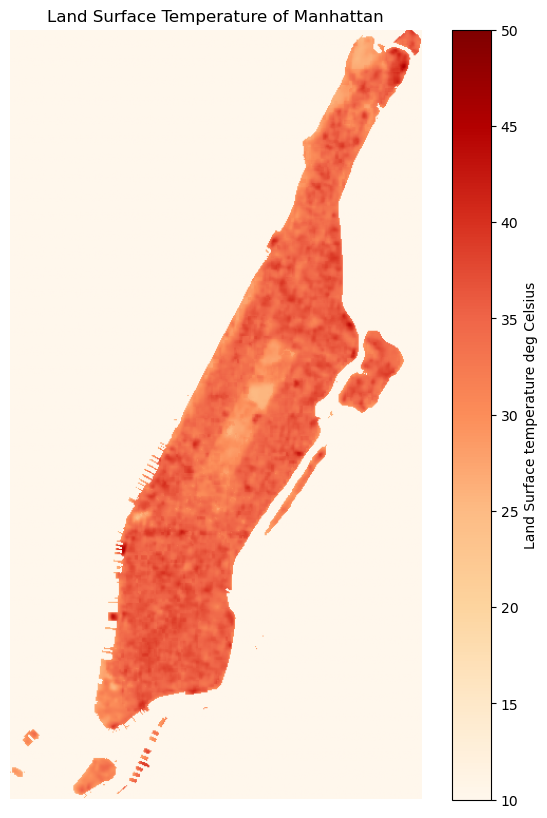

/var/folders/k3/hxk565lj1nd1qqhz81js2b000000gn/T/ipykernel_5932/1922402622.py:15: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir - red) / (nir + red)


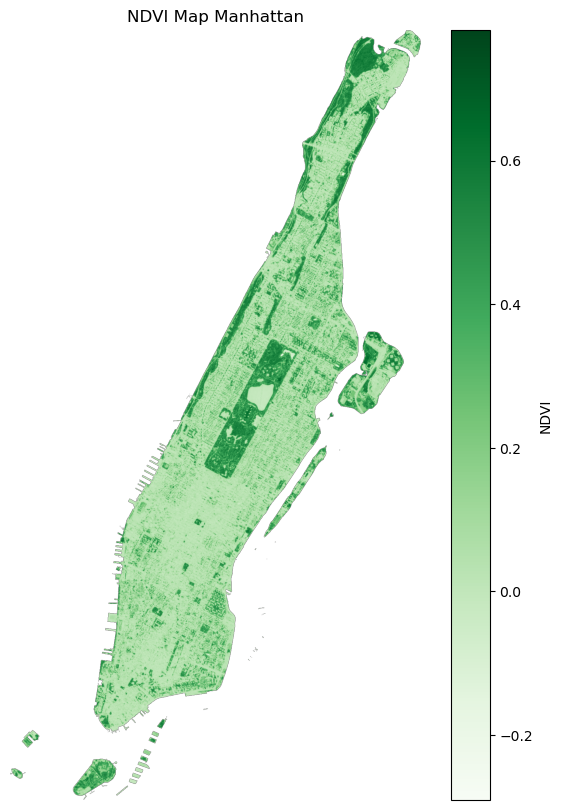

In [8]:
manhattan_temp, manhattan_temp_transform = temp("Manhattan", boroughs, landsat)
manhattan_ndvi, manhattan_ndvi_transform = ndvi_map("Manhattan", boroughs, red_2025, nir_2025)
manhattan_ndvi_matched = reproject_ndvi_to_temp(manhattan_ndvi, manhattan_ndvi_transform, red_2025.crs, manhattan_temp, manhattan_temp_transform, landsat.crs)

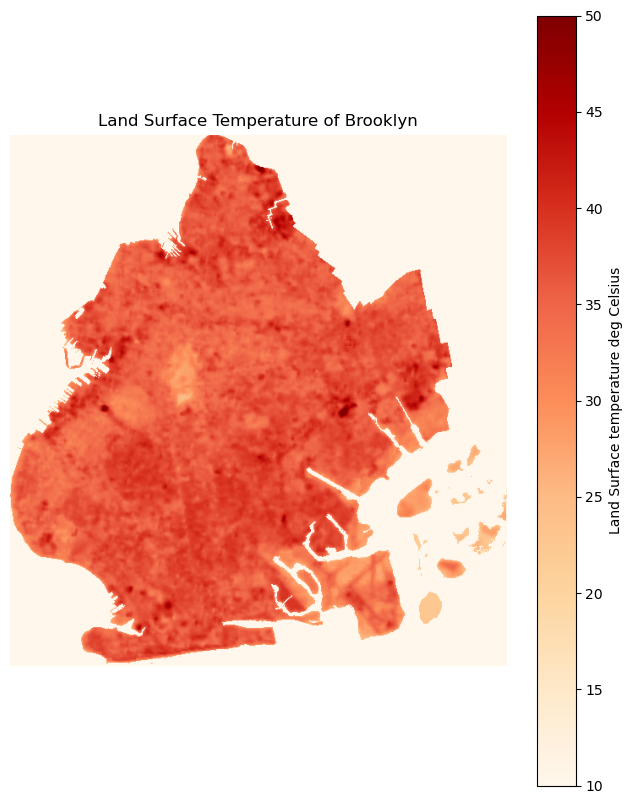

/var/folders/k3/hxk565lj1nd1qqhz81js2b000000gn/T/ipykernel_5932/1922402622.py:15: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir - red) / (nir + red)


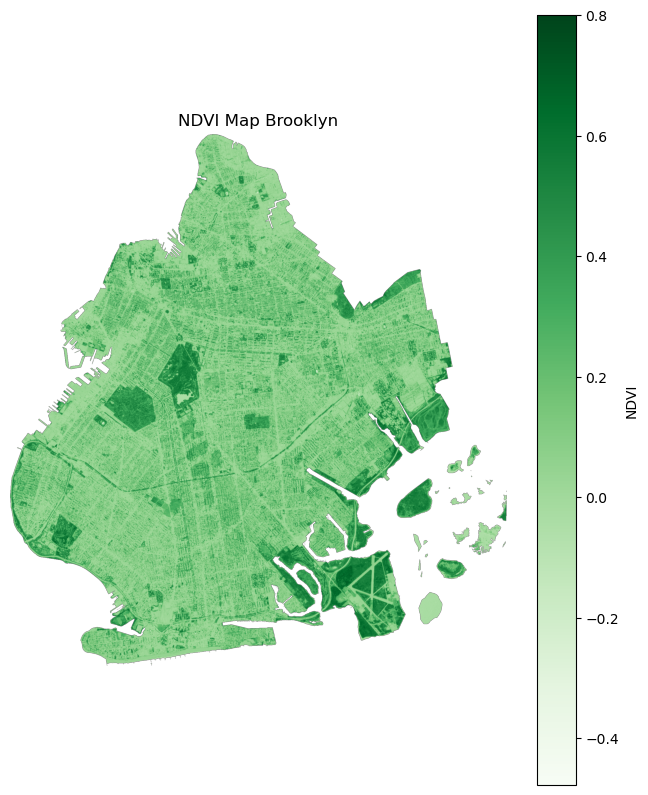

In [9]:
brooklyn_temp, brooklyn_temp_transform = temp("Brooklyn", boroughs, landsat)
brooklyn_ndvi, brooklyn_ndvi_transform= ndvi_map("Brooklyn", boroughs, red_2025, nir_2025)
brooklyn_ndvi_matched = reproject_ndvi_to_temp(brooklyn_ndvi, brooklyn_ndvi_transform, red_2025.crs, brooklyn_temp, brooklyn_temp_transform, landsat.crs)

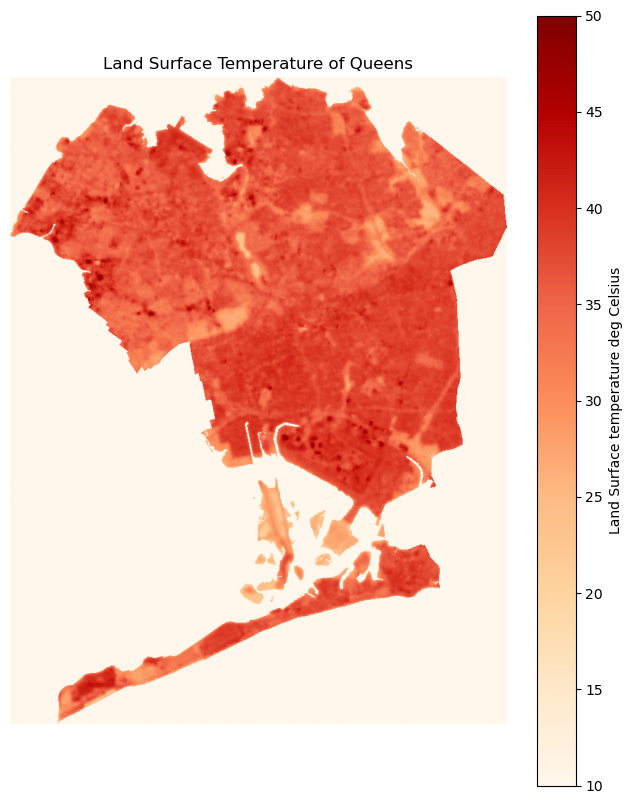

/var/folders/k3/hxk565lj1nd1qqhz81js2b000000gn/T/ipykernel_5932/1922402622.py:15: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir - red) / (nir + red)


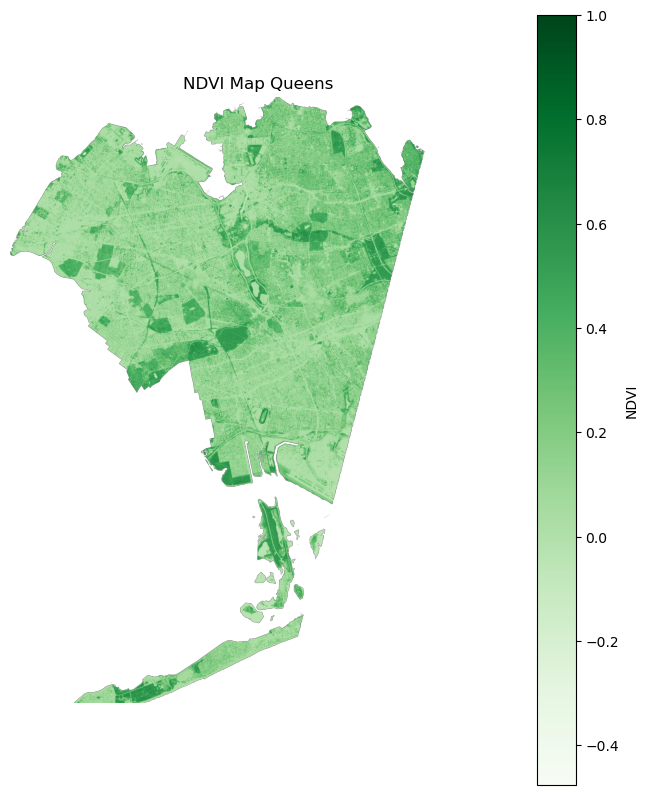

In [10]:
queens_temp, queens_temp_transform = temp("Queens", boroughs, landsat)
queens_ndvi, queens_ndvi_transform= ndvi_map("Queens", boroughs, red_2025, nir_2025)
queens_ndvi_matched = reproject_ndvi_to_temp(queens_ndvi, queens_ndvi_transform, red_2025.crs, queens_temp, queens_temp_transform, landsat.crs)

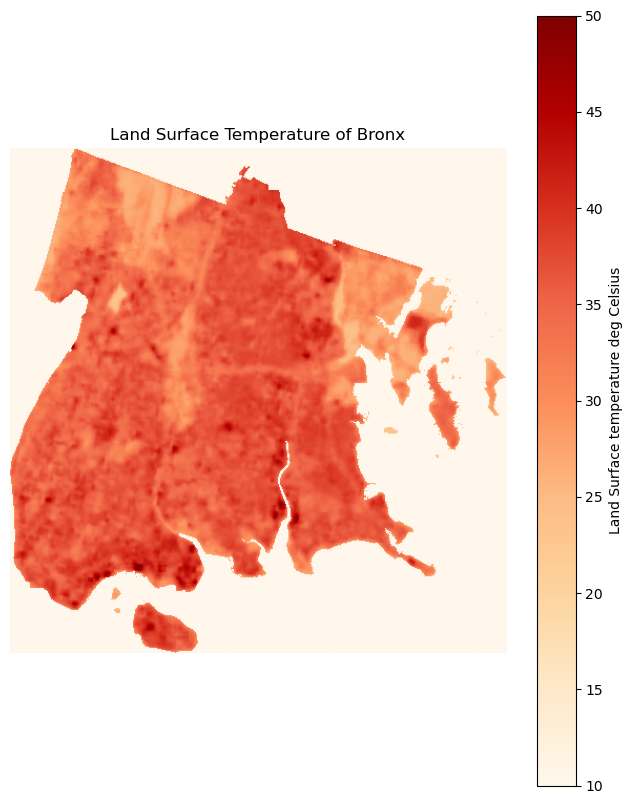

/var/folders/k3/hxk565lj1nd1qqhz81js2b000000gn/T/ipykernel_5932/1922402622.py:15: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir - red) / (nir + red)


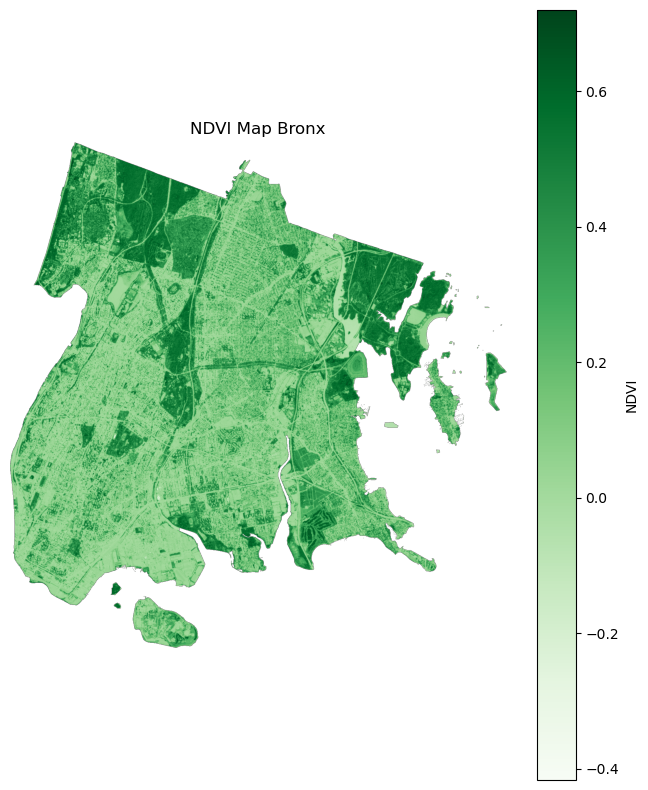

In [11]:
bronx_temp, bronx_temp_transform = temp("Bronx", boroughs, landsat)
bronx_ndvi, bronx_ndvi_transform= ndvi_map("Bronx", boroughs, red_2025, nir_2025)
bronx_ndvi_matched = reproject_ndvi_to_temp(bronx_ndvi, bronx_ndvi_transform, red_2025.crs, bronx_temp, bronx_temp_transform, landsat.crs)

In [12]:
print(f"Manhattan")
manhattan = temp_distance_ndvi(manhattan_ndvi_matched, manhattan_temp)
manhattan

Manhattan


,Distance from high NDVI,Average Temperature
0,0-99m,31.269708
1,100-199m,33.447986
2,200-299m,34.277974


In [13]:
print(f"Brooklyn")
brooklyn = temp_distance_ndvi(brooklyn_ndvi_matched, brooklyn_temp)
brooklyn

Brooklyn


,Distance from high NDVI,Average Temperature
0,0-99m,31.945806
1,100-199m,34.112591
2,200-299m,35.519663


In [14]:
print(f"Queens")
queens = temp_distance_ndvi(queens_ndvi_matched, queens_temp)
queens

Queens


,Distance from high NDVI,Average Temperature
0,0-99m,32.130219
1,100-199m,34.786666
2,200-299m,35.941891


In [15]:
print(f"Bronx")
bronx = temp_distance_ndvi(bronx_ndvi_matched, bronx_temp)
bronx

Bronx


,Distance from high NDVI,Average Temperature
0,0-99m,31.484483
1,100-199m,34.318516
2,200-299m,35.605562


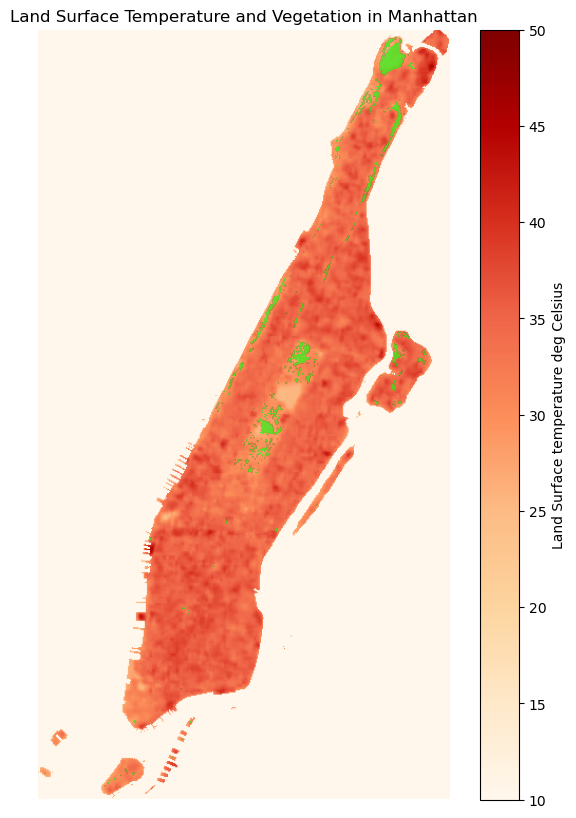

In [16]:
vegetation_map(manhattan_ndvi_matched, manhattan_temp, "Manhattan")

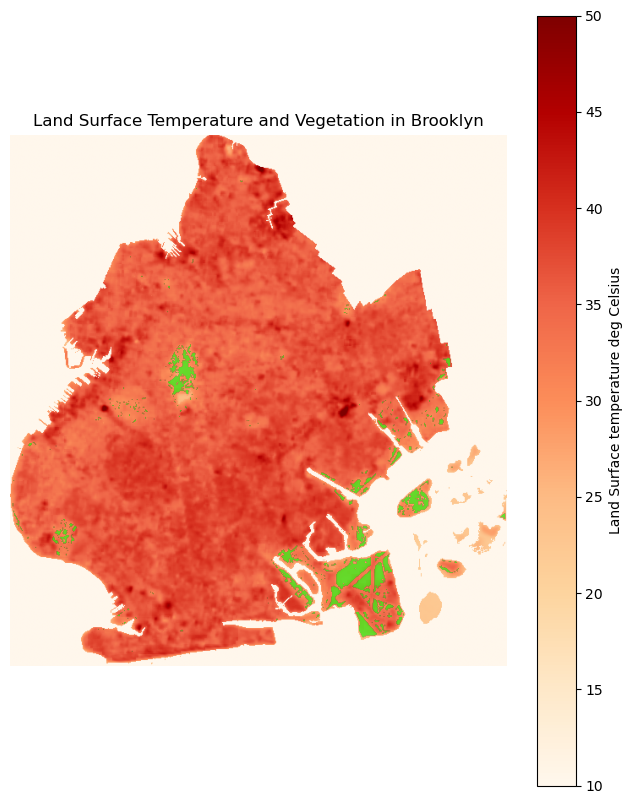

In [17]:
vegetation_map(brooklyn_ndvi_matched, brooklyn_temp, "Brooklyn")

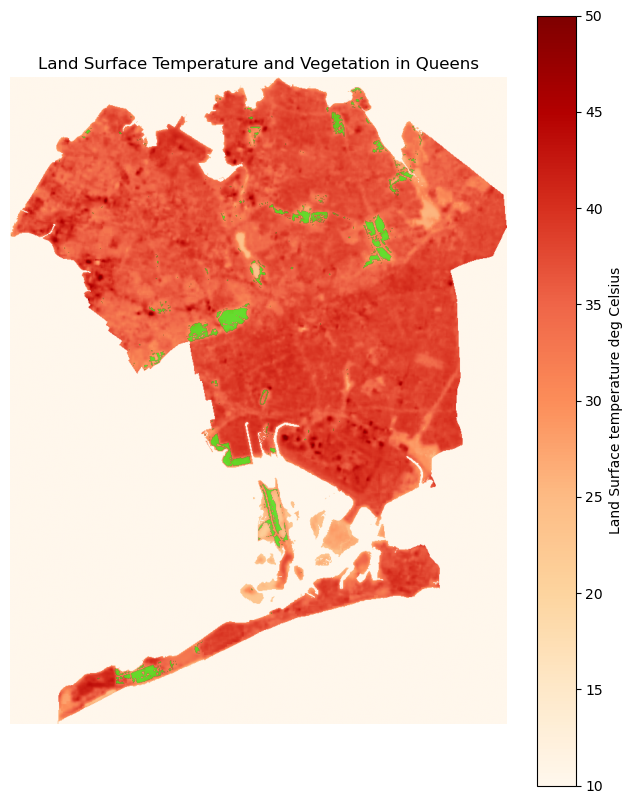

In [18]:
vegetation_map(queens_ndvi_matched, queens_temp, "Queens")

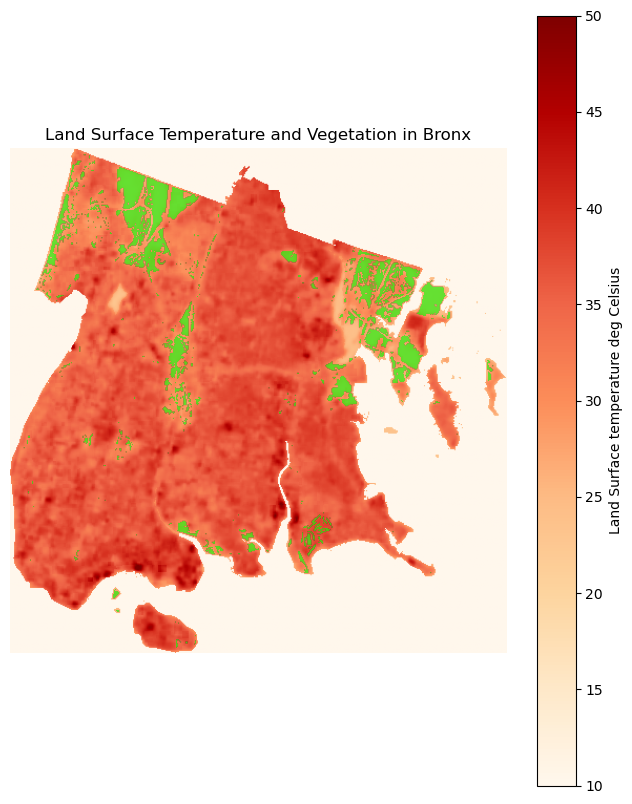

In [19]:
vegetation_map(bronx_ndvi_matched, bronx_temp, "Bronx")

Comparison of landsat vs sentinel ndvi 

### Results and Conclusion:
Every borough has a clear and consistent temperature gradient. The higher the distance from dense vegetation, the higher the land surface temperature. The Bronx has the largest temperature rise, +4.12 degrees Celsius, in the 200-299m buffer compared to the 0-99m buffer. On the other hand, Manhattan has the smallest change from the 0-99m buffer and 200-299m buffer, +3.01 degrees Celsius higher in the outer buffer than the inner buffer. More research could be conducted into why Manhattan has the smallest gradient; perhaps it is because of the borough's dense environment. 

Next Steps:
- Add Staten Island, which was skipped due to data being split across two different tiles in the Sentinel data.
- Extend the distance and create more buffers.
- Add more years to compare the cooling effect over different years.
- Look at the vegetation type to see whether trees have a more cooling effect than other vegetation types.

## Why Sentinel-2 instead of Landsat for NDVI:
According to online sources, Sentinel-2 is better for NDVI analysis, which is why I used it in my project. Sentinel-2 has a better resolution than Landsat. In my case, it wouldn't have mattered which one I used because I ended up converting the Sentinel-2 resolution to 30m to match my Landsat thermal resolution. Here I am looking at the difference in the NDVI map of Sentinel vs Landsat:  

/var/folders/k3/hxk565lj1nd1qqhz81js2b000000gn/T/ipykernel_5932/1922402622.py:15: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir - red) / (nir + red)
/var/folders/k3/hxk565lj1nd1qqhz81js2b000000gn/T/ipykernel_5932/1922402622.py:15: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir - red) / (nir + red)


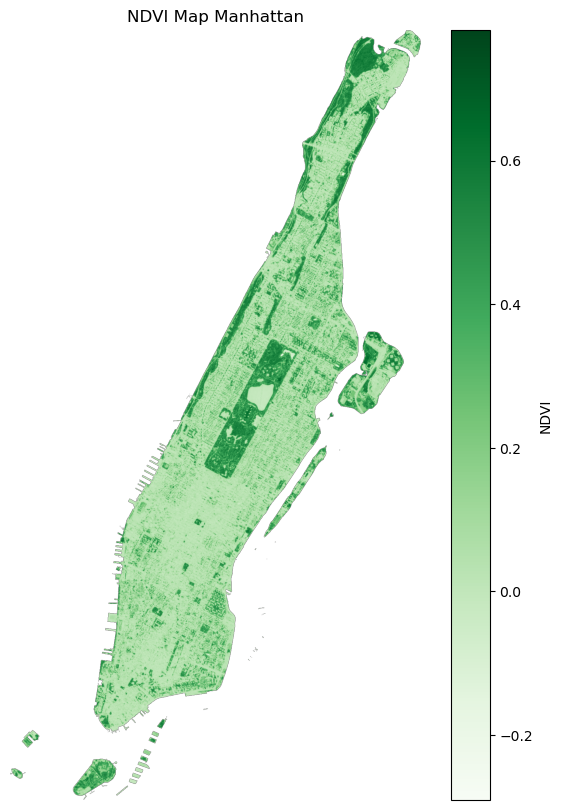

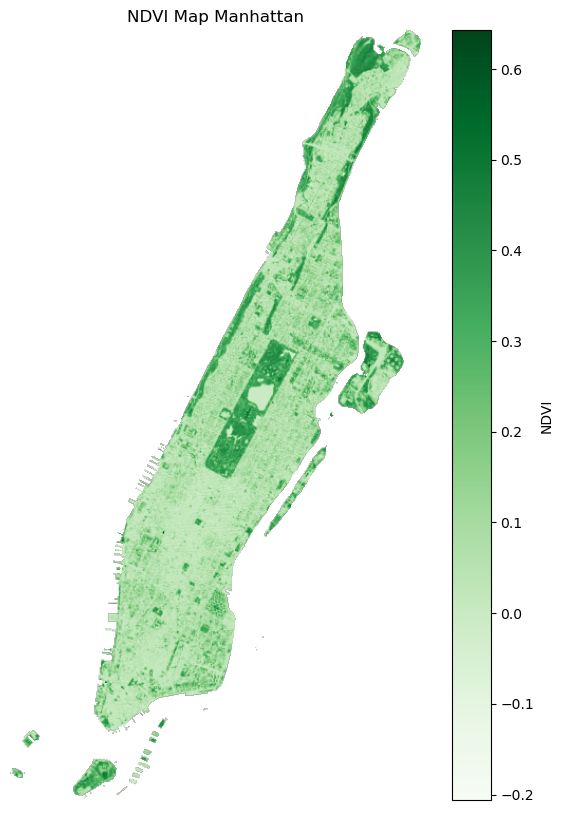

In [20]:
manhattan_ndvi_sentinel = ndvi_map("Manhattan", boroughs, red_2025, nir_2025)
manhattan_ndvi_landsat = ndvi_map("Manhattan", boroughs, red_landsat, nir_landsat)


## Sources:
- “Copernicus Browser.” Copernicus Browser, browser.dataspace.copernicus.eu/?zoom=5&lat=50.16282&lng=20.78613&themeId=DEFAULT-THEME&demSource3D=%22MAPZEN%22&cloudCoverage=30&dateMode=SINGLE. Accessed 19 May 2026.
- “Matplotlib.Colors.ListedColormap — Matplotlib 3.10.9 Documentation.” Matplotlib.org, matplotlib.org/stable/api/_as_gen/matplotlib.colors.ListedColormap.html. Accessed 19 May 2026.
- “Reprojection — Rasterio 1.4.4 Documentation.” Readthedocs.Io, rasterio.readthedocs.io/en/stable/topics/reproject.html. Accessed 19 May 2026.
- Scientific Python Forum. “Distance_transform_edt — SciPy v1.17.0 Manual.” Scipy.org, docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.distance_transform_edt.html. Accessed 19 May 2026.
- “USGS EROS Archive - Sentinel-2 - Comparison of Sentinel-2 and Landsat.” USGS, www.usgs.gov/centers/eros/science/usgs-eros-archive-sentinel-2-comparison-sentinel-2-and-landsat. Accessed 19 May 2026.
- USGS-U.S. Geological Survey. “EarthExplorer.” USGS - U.S. Geological Survey, earthexplorer.usgs.gov/. Accessed 19 May 2026.